In [110]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

rows = 500

channels = ["Instagram","Facebook Ads","Google Ads","Email","Organic"]
categories = ["Electronics","Fashion","Home","Beauty","Sports"]
customer_type = ["New","Repeat"]

start_date = datetime(2025,1,1)

data = {
    "Order_ID":[f"ORD{i}" for i in range(1001,1501)],
    
    "Order_Date":[start_date + timedelta(days=np.random.randint(0,120))
                  for i in range(rows)],
    
    "Customer_ID":[f"CUST{np.random.randint(100,400)}"
                   for i in range(rows)],
    
    "Channel":np.random.choice(channels,rows),
    
    "Product_Category":np.random.choice(categories,rows),
    
    "Units_Sold":np.random.randint(1,5,rows),
    
    "Price":np.round(np.random.uniform(20,200,rows),2),
    
    "Customer_Type":np.random.choice(customer_type,rows,p=[0.65,0.35])
}

df = pd.DataFrame(data)

df["Revenue"] = df["Units_Sold"] * df["Price"]

# Marketing cost logic
cost = []

for ch in df["Channel"]:
    
    if ch == "Organic":
        cost.append(0)
        
    elif ch == "Email":
        cost.append(np.random.uniform(1,6))
        
    elif ch == "Instagram":
        cost.append(np.random.uniform(5,25))
        
    elif ch == "Facebook Ads":
        cost.append(np.random.uniform(6,22))
        
    else:
        cost.append(np.random.uniform(8,28))

df["Marketing_Cost"] = np.round(cost,2)

df.to_csv("marketing_roi_dataset.csv",index=False)

print("Dataset generated successfully")
df.head()

Dataset generated successfully


,Order_ID,Order_Date,Customer_ID,Channel,Product_Category,Units_Sold,Price,Customer_Type,Revenue,Marketing_Cost
0,ORD1001,2025-04-13,CUST112,Email,Home,1,166.51,New,166.51,2.23
1,ORD1002,2025-02-21,CUST135,Google Ads,Beauty,3,130.74,New,392.22,17.68
2,ORD1003,2025-04-03,CUST272,Email,Sports,3,75.13,Repeat,225.39,4.74
3,ORD1004,2025-01-15,CUST119,Instagram,Sports,1,132.30,New,132.30,14.48
4,ORD1005,2025-04-17,CUST363,Email,Home,3,114.87,Repeat,344.61,1.29


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          500 non-null    object        
 1   Order_Date        500 non-null    datetime64[ns]
 2   Customer_ID       500 non-null    object        
 3   Channel           500 non-null    object        
 4   Product_Category  500 non-null    object        
 5   Units_Sold        500 non-null    int32         
 6   Price             500 non-null    float64       
 7   Customer_Type     500 non-null    object        
 8   Revenue           500 non-null    float64       
 9   Marketing_Cost    500 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int32(1), object(5)
memory usage: 37.2+ KB


In [112]:
df.describe

<bound method NDFrame.describe of     Order_ID Order_Date Customer_ID       Channel Product_Category  \
0    ORD1001 2025-04-13     CUST112         Email             Home   
1    ORD1002 2025-02-21     CUST135    Google Ads           Beauty   
2    ORD1003 2025-04-03     CUST272         Email           Sports   
3    ORD1004 2025-01-15     CUST119     Instagram           Sports   
4    ORD1005 2025-04-17     CUST363         Email             Home   
..       ...        ...         ...           ...              ...   
495  ORD1496 2025-01-26     CUST125       Organic           Beauty   
496  ORD1497 2025-04-09     CUST272  Facebook Ads             Home   
497  ORD1498 2025-02-19     CUST399     Instagram          Fashion   
498  ORD1499 2025-01-25     CUST232         Email          Fashion   
499  ORD1500 2025-01-24     CUST217         Email           Sports   

     Units_Sold   Price Customer_Type  Revenue  Marketing_Cost  
0             1  166.51           New   166.51            2.

In [113]:
# Which marketing channels generate the highest revenue?
revenue_by_channel = df.groupby('Channel')['Revenue'].sum().sort_values(ascending=False)
revenue_by_channel

Channel
Instagram       29926.05
Google Ads      29784.13
Organic         27088.19
Facebook Ads    26384.40
Email           23936.91
Name: Revenue, dtype: float64

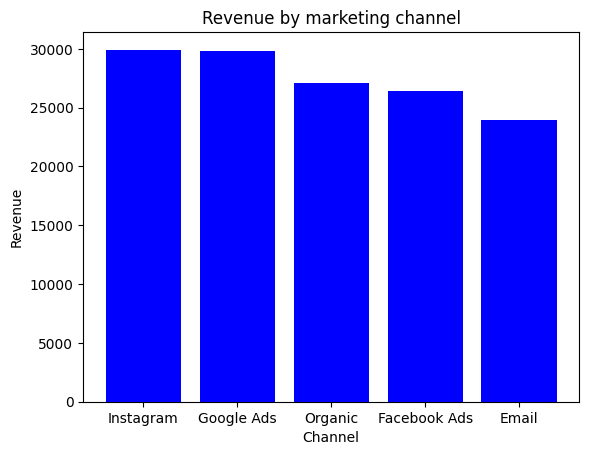

In [114]:
import matplotlib.pyplot as plt
plt.bar(revenue_by_channel.index,revenue_by_channel.values ,color = 'blue')
plt.title("Revenue by marketing channel")
plt.xlabel('Channel')
plt.ylabel('Revenue')
plt.show()

In [115]:
#Which channels generate the most orders?
channel_most_orders = df.groupby('Channel')['Order_ID'].count().sort_values(ascending=True)
channel_most_orders

Channel
Email            88
Facebook Ads     99
Google Ads      102
Organic         103
Instagram       108
Name: Order_ID, dtype: int64

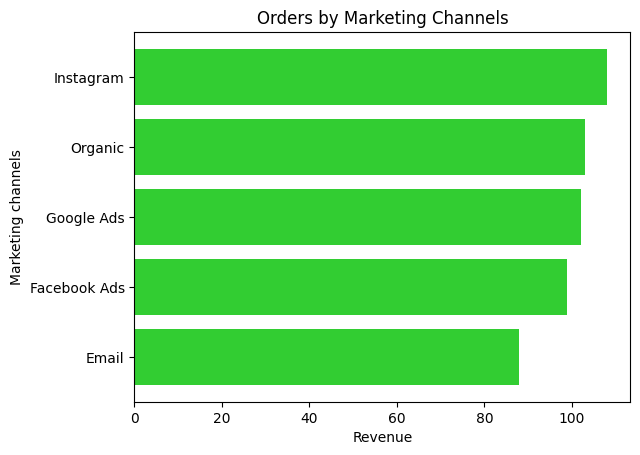

In [116]:
plt.barh(channel_most_orders.index,channel_most_orders.values,color = 'limegreen')
plt.title("Orders by Marketing Channels")
plt.xlabel('Revenue')
plt.ylabel("Marketing channels")
plt.show()

In [117]:
#Which channels bring the highest product sales?
high_Product_sales = df.groupby('Channel')['Units_Sold'].sum().sort_values(ascending=False)
high_Product_sales

Channel
Instagram       267
Google Ads      262
Organic         256
Facebook Ads    244
Email           217
Name: Units_Sold, dtype: int32

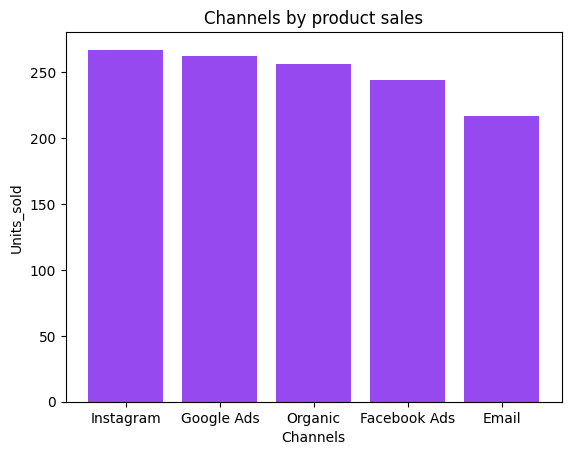

In [118]:
plt.bar(high_Product_sales.index, high_Product_sales.values ,
        color="#9749f0")
plt.title("Channels by product sales")
plt.xlabel('Channels')
plt.ylabel('Units_sold')
plt.show()


In [119]:
#Which marketing channels cost the most?
marketing_cost = df.groupby('Channel')['Marketing_Cost'].sum().sort_values(ascending=False)
marketing_cost

Channel
Google Ads      1803.78
Instagram       1615.87
Facebook Ads    1401.03
Email            320.68
Organic            0.00
Name: Marketing_Cost, dtype: float64

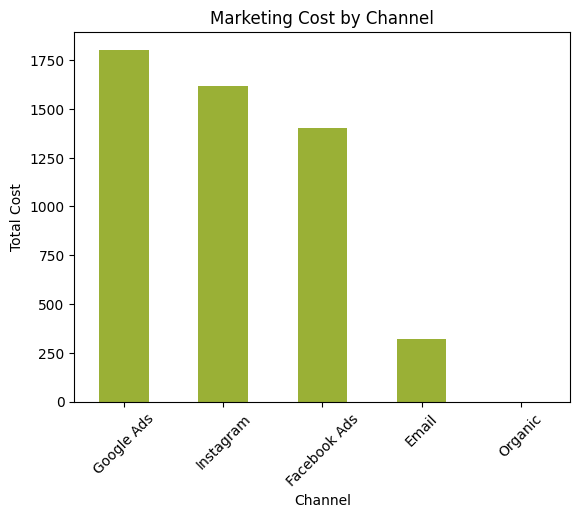

In [120]:
marketing_cost.plot(kind="bar",color="#9ab036",rot=45)

plt.title("Marketing Cost by Channel")
plt.ylabel("Total Cost")
plt.xlabel("Channel")

plt.show()

In [121]:
cost_per_order = marketing_cost/ channel_most_orders
cost_per_order.sort_values(ascending=False)

Channel
Google Ads      17.684118
Instagram       14.961759
Facebook Ads    14.151818
Email            3.644091
Organic          0.000000
dtype: float64

In [122]:
#ROI=(Revenue−MarketingCost)/MarketingCost 
roi = (revenue_by_channel - marketing_cost) / marketing_cost
roi

Channel
Email           73.644225
Facebook Ads    17.832145
Google Ads      15.512064
Instagram       17.520085
Organic               inf
dtype: float64

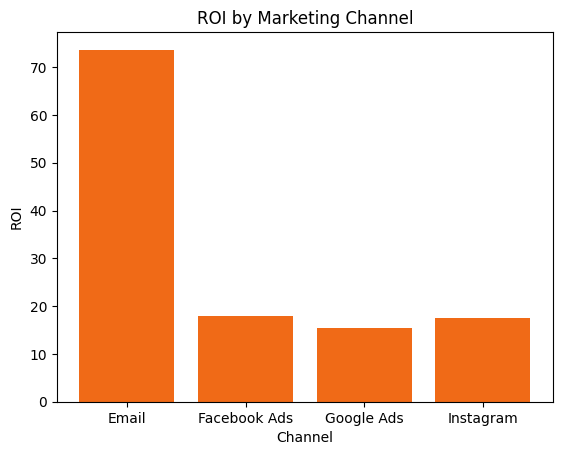

In [123]:
plt.bar(roi.index, roi.values ,
        color="#f06a17")
plt.title("ROI by Marketing Channel")
plt.ylabel("ROI")
plt.xlabel("Channel")
plt.show()

In [124]:
new_customers = df[df['Customer_Type'] == 'New']
new_customer_channel = new_customers.groupby('Channel')['Customer_ID'].nunique()
new_customer_channel

Channel
Email           51
Facebook Ads    57
Google Ads      67
Instagram       60
Organic         67
Name: Customer_ID, dtype: int64

In [125]:
repeat_customers = df[df['Customer_Type'] == 'Repeat']
repeat_customer_channel = new_customers.groupby('Channel')['Customer_ID'].nunique()
repeat_customer_channel

Channel
Email           51
Facebook Ads    57
Google Ads      67
Instagram       60
Organic         67
Name: Customer_ID, dtype: int64

In [126]:
channels_summary = pd.DataFrame({
    "Revenue" : revenue_by_channel,
    "Orders" : channel_most_orders,
    "Cost" : marketing_cost,
    "ROI":roi
})
channels_summary
channels_summary["CAC"] = marketing_cost / channel_most_orders
channels_summary

,Revenue,Orders,Cost,ROI,CAC
Channel,,,,,
Email,23936.91,88,320.68,73.644225,3.644091
Facebook Ads,26384.40,99,1401.03,17.832145,14.151818
Google Ads,29784.13,102,1803.78,15.512064,17.684118
Instagram,29926.05,108,1615.87,17.520085,14.961759
Organic,27088.19,103,0.00,inf,0.000000


######################################   **Insights**   #########################################


1 - Email marketing generates the highest ROI (73.6) due to extremely low marketing costs, making it the most profitable channel.

2  - Instagram produces the highest revenue and largest number of orders, indicating strong performance in customer acquisition.

3 - Organic traffic generates significant revenue without marketing cost, highlighting the importance of SEO and brand visibility.

4 - Google Ads and Facebook Ads generate strong revenue but require higher marketing investment compared to Email marketing.

5 - Email marketing has the lowest customer acquisition cost, making it the most cost-efficient marketing channel. 

6 - Instagram marketing has the  second highest customer acquisition cost , making it the least efficient marketing channel.

7 - Google Ads has a higher CAC, meaning it is more expensive to acquire customers through paid advertising.

##############################   Recommendations   #######################################

1 - Email marketing has low revenue but high ROI so business need investment in email campaigns to generate more revenue efficiently.

2 - Although Instagram generates the highest revenue, its ROI is lower than Email marketing. The company should optimize ad spending and improve conversion rates.

3 - Organic is best in that way for business but Organic traffic provides revenue without marketing costs, so the business should invest in SEO and content marketing to grow organic traffic further.

4 - Email marketing has low CAC so business should focus on  expanding email campaigns to acquire customers at a lower cost.
 